In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")   # themes: white, dark, ticks
sns.set_palette("deep")      # color themes

In [3]:
df=pd.read_csv('House Price India.csv')

# DATA UNDERSTANDING

In [4]:
df.shape
df.describe()
df.info()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

id                                       14620
Date                                       241
number of bedrooms                          12
number of bathrooms                         29
living area                                865
lot area                                  7451
number of floors                             6
waterfront present                           2
number of views                              5
condition of the house                       5
grade of the house                          10
Area of the house(excluding basement)      781
Area of the basement                       280
Built Year                                 116
Renovation Year                             68
Postal Code                                 70
Lattitude                                 4662
Longitude                                  716
living_area_renov                          665
lot_area_renov                            6835
Number of schools nearby                     3
Distance from

# MISSING VALUES

In [5]:
df.isnull().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

# TARGET FEATURE ANALYSIS

<Axes: >

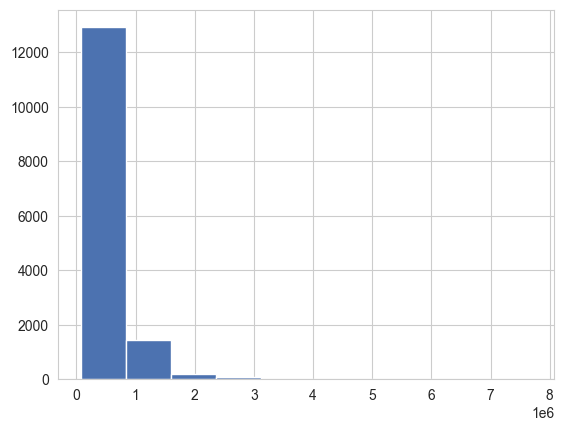

In [6]:
df['Price'].hist()

RIGHT SKEWED SO WE WILL APPLY LOG TRANSFORM

In [7]:
df['Price_log']=np.log1p(df['Price'])

<Axes: xlabel='Price_log', ylabel='Count'>

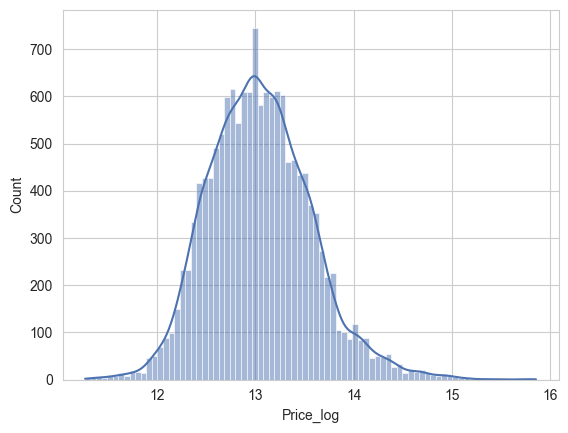

In [8]:
sns.histplot(df['Price_log'], kde=True)

# FEATURE ENGG 

In [9]:
df['Total Area']=df['Area of the house(excluding basement)'] + df['Area of the basement']

current_year=df['Built Year'].max()
df['House_age']=current_year-df['Built Year']

df['Renovated']=(df['Renovation Year']>0).astype(int)

In [10]:
from sklearn.cluster import KMeans

means=KMeans(n_clusters=5,random_state=43)

df['location']=means.fit_predict(df[['Lattitude', 'Longitude']])
df=df.rename(columns={'location':'Location_cluster'})


FEATURE RELATIONSHIPS

In [11]:
corr = df.select_dtypes(include=['number']).corr() *100

compare = pd.DataFrame({
    'Price_corr': corr['Price'],
    'Price_log_corr': corr['Price_log']
})

compare.sort_values(by='Price_log_corr', ascending=False)

,Price_corr,Price_log_corr
Price_log,88.805880,100.000000
Price,100.000000,88.805880
grade of the house,67.181438,71.344287
living area,71.216948,70.504354
Total Area,71.216948,70.504354
living_area_renov,58.492446,62.672803
Area of the house(excluding basement),61.522042,61.175392
number of bathrooms,53.173456,55.878546
Lattitude,29.748998,44.256031
number of views,39.597310,34.636399


DROP UNWANTED COLN

In [12]:
df=df.drop(columns=['id','Postal Code','Date','Number of schools nearby','Distance from the airport'])

In [13]:
df=df.drop(columns=['Longitude','Lattitude','Built Year','Renovation Year'])
df=df.drop(columns=['living area','Area of the house(excluding basement)','Area of the basement'])

In [14]:
df=df.drop(columns=['Price'])

Multicollinearity Check

In [15]:
corr=df.select_dtypes(include=['number']).corr()*100
corr

,number of bedrooms,number of bathrooms,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,living_area_renov,lot_area_renov,Price_log,Total Area,House_age,Renovated,Location_cluster
number of bedrooms,100.000000,50.978411,3.441585,17.729354,-0.625666,7.866487,2.659717,35.294548,38.985471,2.940006,34.445528,57.052598,-15.295357,1.585040,-1.727642
number of bathrooms,50.978411,100.000000,8.080588,50.292398,6.010389,18.378864,-12.823196,66.305354,57.052976,7.862704,55.878546,75.351739,-49.812676,4.918816,-2.710336
lot area,3.441585,8.080588,100.000000,-0.413792,2.628220,7.830832,-0.854823,11.054602,14.974383,70.681181,9.666509,17.442007,-5.161506,0.699669,2.319113
number of floors,17.729354,50.292398,-0.413792,100.000000,1.631611,2.015261,-26.992789,46.308234,28.509308,-1.012036,31.772811,35.474318,-48.156521,0.663588,-1.748672
waterfront present,-0.625666,6.010389,2.628220,1.631611,100.000000,40.020615,1.864375,7.983071,8.574293,3.205469,17.182812,10.583731,2.422571,8.614790,1.244043
number of views,7.866487,18.378864,7.830832,2.015261,40.020615,100.000000,5.253316,25.453164,28.145174,7.230046,34.636399,28.772781,5.535707,10.306772,2.766316
condition of the house,2.659717,-12.823196,-0.854823,-26.992789,1.864375,5.253316,100.000000,-15.252975,-9.974319,-0.474834,4.840116,-6.335765,38.171766,-6.160095,-0.681777
grade of the house,35.294548,66.305354,11.054602,46.308234,7.983071,25.453164,-15.252975,100.000000,72.001894,11.672487,71.344287,76.183472,-44.035839,1.410046,-6.429687
living_area_renov,38.985471,57.052976,14.974383,28.509308,8.574293,28.145174,-9.974319,72.001894,100.000000,18.922518,62.672803,75.757094,-32.862508,-0.266703,-1.943238
lot_area_renov,2.940006,7.862704,70.681181,-1.012036,3.205469,7.230046,-0.474834,11.672487,18.922518,100.000000,8.654517,18.031158,-7.287436,0.596916,2.714105


In [16]:
corr=df.select_dtypes(include=['number']).corr() *100
corr['Price_log'].sort_values(ascending=False)

Price_log                 100.000000
grade of the house         71.344287
Total Area                 70.504354
living_area_renov          62.672803
number of bathrooms        55.878546
number of views            34.636399
number of bedrooms         34.445528
number of floors           31.772811
waterfront present         17.182812
Renovated                  12.230985
lot area                    9.666509
lot_area_renov              8.654517
condition of the house      4.840116
Location_cluster           -7.785949
House_age                  -7.900857
Name: Price_log, dtype: float64

# Split Dataset Into Train and Test


In [17]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['Price_log'])
y=df['Price_log']

X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Encoding Columns


In [18]:
X.sample(3)

,number of bedrooms,number of bathrooms,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,living_area_renov,lot_area_renov,Total Area,House_age,Renovated,Location_cluster
3465,3,1.0,4128,1.0,0,0,4,7,1510,4538,1100,73,0,4
12030,3,1.0,5000,1.0,0,0,4,6,1180,7500,1260,47,0,2
5610,4,2.5,10533,2.0,0,0,3,9,2760,8603,2740,18,0,2


OHE for Location_cluster Coln

In [19]:
X_train=pd.get_dummies(X_train,columns=['Location_cluster'])
X_test=pd.get_dummies(X_test,columns=['Location_cluster'])

X_train,X_test=X_train.align(X_test,join='left',axis=1,fill_value=0)

In [ ]:
#Converting all coln to int coz models expect numeric values not bool/float
X_train=X_train.astype(int)
X_test=X_test.astype(int)

# MODEL TRAINING